# H2 — Génération procédurale de niveaux avec WFC et CP-SAT  
### Timothé Le Bronec ing2 SCIA


In [1]:
import random
from collections import deque, Counter
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from ortools.sat.python import cp_model
    ORTOOLS_AVAILABLE = True
except Exception as e:
    ORTOOLS_AVAILABLE = False
    print("OR-Tools non disponible :", e)

random.seed(7)
np.random.seed(7)

MAP_H, MAP_W = 32, 56


## 1. Outils communs


In [2]:
@dataclass
class TileSet:
    name: str
    tiles: list
    chars: dict
    colors: dict
    passable: set
    weights: dict
    adjacency: dict
    special: dict
    labels: dict = None


def neighbors4(r, c, h, w):
    for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < h and 0 <= nc < w:
            yield nr, nc


def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])


def compatible(tileset, a, b):
    return b in tileset.adjacency.get(a, set()) and a in tileset.adjacency.get(b, set())


def tile_rgb(grid, tileset):
    h, w = grid.shape
    rgb = np.zeros((h, w, 3))
    for tile in tileset.tiles:
        rgb[grid == tile] = tileset.colors[tile]
    return rgb


def display_legend(ax, grid, tileset):
    counts = Counter(grid.flatten())
    labels = tileset.labels or {t: t for t in tileset.tiles}
    ax.axis("off")
    ax.set_title("Légende", fontsize=12, fontweight="bold", pad=8)
    y = 0.96
    step = 0.082 if len(tileset.tiles) >= 10 else 0.105
    for tile in tileset.tiles:
        color = tileset.colors[tile]
        ax.add_patch(plt.Rectangle((0.02, y-0.045), 0.12, 0.07, color=color, transform=ax.transAxes, clip_on=False))
        ax.text(0.08, y-0.01, tileset.chars[tile], ha="center", va="center", fontsize=10, transform=ax.transAxes)
        ax.text(0.18, y-0.01, f"{labels[tile]} : {counts[tile]}", ha="left", va="center", fontsize=9, transform=ax.transAxes)
        y -= step


def display_level(grid, tileset, title="", show_text=True, figsize=(13, 6), show_legend=True):
    if grid is None:
        print("Aucune grille à afficher.")
        return
    h, w = grid.shape
    rgb = tile_rgb(grid, tileset)
    if show_legend:
        fig, (ax_map, ax_leg) = plt.subplots(1, 2, figsize=figsize, gridspec_kw={"width_ratios": [4, 1.55]})
    else:
        fig, ax_map = plt.subplots(1, 1, figsize=figsize)
        ax_leg = None
    ax_map.imshow(rgb)
    ax_map.set_xticks([]); ax_map.set_yticks([])
    ax_map.set_title(title, fontsize=13, fontweight="bold")
    if show_text:
        fs = max(6, min(10, 180 // max(h, w)))
        for r in range(h):
            for c in range(w):
                ax_map.text(c, r, tileset.chars[grid[r,c]], ha="center", va="center", fontsize=fs)
    if show_legend:
        display_legend(ax_leg, grid, tileset)
    plt.tight_layout(); plt.show()


def shortest_path(grid, start, goal, passable):
    h, w = grid.shape
    if grid[start] not in passable or grid[goal] not in passable:
        return None
    q = deque([start])
    parent = {start: None}
    while q:
        cur = q.popleft()
        if cur == goal:
            path = []
            while cur is not None:
                path.append(cur)
                cur = parent[cur]
            return path[::-1]
        for nb in neighbors4(*cur, h, w):
            nr, nc = nb
            if nb not in parent and grid[nr, nc] in passable:
                parent[nb] = cur
                q.append(nb)
    return None


def reachable_ratio(grid, start, passable):
    h, w = grid.shape
    if grid[start] not in passable:
        return 0
    q = deque([start])
    seen = {start}
    while q:
        r, c = q.popleft()
        for nr, nc in neighbors4(r, c, h, w):
            if (nr, nc) not in seen and grid[nr, nc] in passable:
                seen.add((nr, nc))
                q.append((nr, nc))
    total = int(np.isin(grid, list(passable)).sum())
    return len(seen) / max(total, 1)


def invalid_adjacency_count(grid, tileset):
    h, w = grid.shape
    bad = 0; total = 0
    for r in range(h):
        for c in range(w):
            for nr, nc in [(r+1, c), (r, c+1)]:
                if 0 <= nr < h and 0 <= nc < w:
                    total += 1
                    if not compatible(tileset, grid[r,c], grid[nr,nc]):
                        bad += 1
    return bad, total


def level_metrics(grid, tileset):
    counts = Counter(grid.flatten())
    metrics = {f"nb_{t}": counts[t] for t in tileset.tiles}
    start = tuple(tileset.special["start"])
    goal = tuple(tileset.special["goal"])
    path = shortest_path(grid, start, goal, tileset.passable)
    metrics["chemin_existe"] = path is not None
    metrics["longueur_chemin"] = None if path is None else len(path)-1
    metrics["ratio_connectivite"] = reachable_ratio(grid, start, tileset.passable)
    metrics["variete_tuiles"] = sum(1 for t in tileset.tiles if counts[t] > 0)
    bad, total = invalid_adjacency_count(grid, tileset)
    metrics["adjacences_invalides"] = bad
    metrics["taux_adjacences_valides"] = 1 - bad / max(total, 1)
    return metrics


## 2. Tilesets


In [3]:
dungeon = TileSet(
    name="Donjon",
    tiles=["wall", "floor", "water", "spawn", "exit", "enemy", "treasure"],
    chars={"wall":"█", "floor":"·", "water":"~", "spawn":"S", "exit":"X", "enemy":"E", "treasure":"T"},
    labels={"wall":"Mur", "floor":"Sol", "water":"Eau", "spawn":"Départ", "exit":"Sortie", "enemy":"Ennemi", "treasure":"Trésor"},
    colors={
        "wall": (0.10,0.10,0.11), "floor": (0.60,0.56,0.48), "water": (0.15,0.32,0.68),
        "spawn": (0.15,0.80,0.25), "exit": (0.90,0.12,0.10),
        "enemy": (0.70,0.10,0.72), "treasure": (0.95,0.78,0.08)
    },
    passable={"floor", "spawn", "exit", "enemy", "treasure"},
    weights={"wall": 12, "floor": 18, "water": 1, "spawn": 0, "exit": 0, "enemy": 3, "treasure": 2},
    adjacency={},
    special={"start": (7,2), "goal": (7,25)}
)
dungeon.adjacency = {
    "wall": {"wall", "floor",  "water", "spawn", "exit"},
    "floor": {"wall", "floor",  "water", "spawn", "exit", "enemy", "treasure"},
    "water": {"wall", "floor", "water"},
    "spawn": {"wall", "floor"},
    "exit": {"wall", "floor"},
    "enemy": {"floor", "enemy", "treasure"},
    "treasure": {"floor", "enemy", "treasure"}
}

island = TileSet(
    name="Ile / biomes",
    tiles=["ocean", "beach", "grass", "forest", "mountain", "village", "port", "rune", "resource", "monster"],
    chars={"ocean":"≈", "beach":"░", "grass":"·", "forest":"♣", "mountain":"▲", "village":"V", "port":"P", "rune":"Ω", "resource":"R", "monster":"M"},
    labels={"ocean":"Océan", "beach":"Plage", "grass":"Prairie", "forest":"Forêt", "mountain":"Montagne", "village":"Ville", "port":"Port", "rune":"Ruine", "resource":"Ressource", "monster":"Monstre"},
    colors={
        "ocean": (0.05,0.25,0.70), "beach": (0.90,0.78,0.40), "grass": (0.42,0.70,0.25),
        "forest": (0.05,0.38,0.12), "mountain": (0.42,0.42,0.42), "village": (0.72,0.40,0.22),
        "port": (0.45,0.24,0.10), "rune": (0.55,0.45,0.75), "resource": (0.95,0.80,0.12), "monster": (0.70,0.10,0.10)
    },
    passable={"beach", "grass", "forest", "village", "port", "rune", "resource", "monster"},
    weights={"ocean": 10, "beach": 5, "grass": 16, "forest": 7, "mountain": 4, "village": 1, "port": 1, "rune": 1, "resource": 2, "monster": 2},
    adjacency={},
    special={"start": (8,3), "goal": (7,24)}
)
island.adjacency = {
    "ocean": {"ocean", "beach", "port"},
    "beach": {"ocean", "beach", "grass", "village", "port", "resource"},
    "grass": {"beach", "grass", "forest", "mountain", "village", "rune", "resource", "monster", "port"},
    "forest": {"grass", "forest", "mountain", "resource", "monster", "village", "rune"},
    "mountain": {"grass", "forest", "mountain", "rune"},
    "village": {"beach", "grass", "forest", "village"},
    "port": {"ocean", "beach", "grass", "port"},
    "rune": {"grass", "forest", "mountain", "rune"},
    "resource": {"beach", "grass", "forest"},
    "monster": {"grass", "forest", "monster"}
}


## 3. Générateurs structurés CP-SAT


In [4]:
# Générateurs structurés CP-SAT uniquement
# Les anciennes fonctions spécialisées hors WFC/CP-SAT ont été supprimées.


def clamp(v, lo, hi):
    return max(lo, min(hi, v))


def zone_cells(center, radius, h, w):
    """Retourne une petite zone en losange autour d'un centre."""
    r0, c0 = center
    cells = []
    for r in range(r0-radius, r0+radius+1):
        for c in range(c0-radius, c0+radius+1):
            if 0 <= r < h and 0 <= c < w and manhattan((r, c), center) <= radius:
                cells.append((r, c))
    return cells


def island_base_mask(h, w):
    """
    Calcule des zones candidates pour l'île.
    Ce masque ne génère pas la carte finale : il sert seulement à fournir
    au modèle CP-SAT des positions plausibles pour océan / plage / intérieur.
    """
    cy = h * 0.50 + random.uniform(-h*0.05, h*0.05)
    cx = w * 0.50 + random.uniform(-w*0.05, w*0.05)
    ry = h * random.uniform(0.33, 0.43)
    rx = w * random.uniform(0.33, 0.43)
    phase = np.random.rand(4) * 2*np.pi
    score = np.zeros((h, w), dtype=float)
    for r in range(h):
        for c in range(w):
            y = (r - cy) / ry
            x = (c - cx) / rx
            angle = np.arctan2(y, x)
            radial = np.sqrt(x*x + y*y)
            boundary = 1.0
            boundary += 0.18*np.sin(3*angle + phase[0])
            boundary += 0.11*np.sin(5*angle + phase[1])
            boundary += 0.08*np.cos(7*angle + phase[2])
            boundary += 0.06*np.sin((r*0.45 + c*0.23) + phase[3])
            score[r, c] = boundary - radial
    return score


# Génération d’île structurée avec contraintes globales CP-SAT.
def cpsat_generate_island_structured(h, w, time_limit=6, verbose=False):
    """
    Génère une île structurée avec CP-SAT de manière robuste.

    Différence avec l'ancienne version : CP-SAT ne choisit plus toutes les tuiles
    de la carte, car le mélange "forme imposée + grandes zones + adjacency"
    rendait le modèle souvent insoluble. Ici :
    - un masque irrégulier fixe les zones ocean / beach / land ;
    - CP-SAT choisit les centres des ports, villes, ruines, ressources et monstres ;
    - CP-SAT impose les nombres et les distances minimales ;
    - les petites zones sont ensuite peintes autour des centres validés.

    La génération reste donc bien CP-SAT pour la partie structurante.
    """
    if not ORTOOLS_AVAILABLE:
        return None

    score = island_base_mask(h, w)

    # 1) Base lisible et toujours valide pour l'île.
    grid = np.full((h, w), "ocean", dtype=object)
    for r in range(h):
        for c in range(w):
            s = score[r, c]
            if r in (0, h-1) or c in (0, w-1) or s < -0.08:
                grid[r, c] = "ocean"
            elif s < 0.14:
                grid[r, c] = "beach"
            else:
                # Variations intérieures simples mais compatibles avec l'adjacence.
                noise = 0.45*np.sin(r*0.41 + c*0.19) + 0.35*np.cos(r*0.17 - c*0.33)
                if s > 0.55 and noise > 0.52:
                    grid[r, c] = "mountain"
                elif s > 0.35 and noise < -0.35:
                    grid[r, c] = "forest"
                else:
                    grid[r, c] = "grass"

    # Sécurité : les points de métriques doivent être sur terre.
    for r, c in [island.special["start"], island.special["goal"]]:
        if 0 <= r < h and 0 <= c < w:
            grid[r, c] = "grass"

    # Modèle CP-SAT principal.
    model = cp_model.CpModel()

    def zone_is_allowed(center, radius, allowed_tiles):
        cells = zone_cells(center, radius, h, w)
        return cells and all(grid[r, c] in allowed_tiles for r, c in cells)

    # 2) Candidats filtrés : on évite de demander à CP-SAT l'impossible.
    village_candidates = [
        (r, c) for r in range(2, h-2) for c in range(2, w-2)
        if zone_is_allowed((r, c), 1, {"grass", "forest", "beach"})
    ]
    rune_candidates = [
        (r, c) for r in range(2, h-2) for c in range(2, w-2)
        if zone_is_allowed((r, c), 1, {"grass", "forest", "mountain"})
    ]
    port_candidates = [
        (r, c) for r in range(2, h-2) for c in range(2, w-2)
        if grid[r, c] == "beach" and any(grid[nr, nc] == "ocean" for nr, nc in neighbors4(r, c, h, w))
    ]
    resource_candidates = [
        (r, c) for r in range(1, h-1) for c in range(1, w-1)
        if grid[r, c] in {"grass", "forest", "beach"}
    ]
    monster_candidates = [
        (r, c) for r in range(1, h-1) for c in range(1, w-1)
        if grid[r, c] in {"grass", "forest"}
    ]

    random.shuffle(village_candidates)
    random.shuffle(rune_candidates)
    random.shuffle(port_candidates)
    random.shuffle(resource_candidates)
    random.shuffle(monster_candidates)

    # On limite les candidats pour garder un modèle rapide, mais assez large.
    village_candidates = village_candidates[:180]
    rune_candidates = rune_candidates[:180]
    port_candidates = port_candidates[:160]
    resource_candidates = resource_candidates[:220]
    monster_candidates = monster_candidates[:220]

    area = h * w
    wanted_villages = clamp(area // 650, 2, 4)
    wanted_ports = clamp(area // 800, 2, 4)
    wanted_runes = clamp(area // 780, 2, 4)
    wanted_resources = clamp(area // 450, 3, 7)
    wanted_monsters = clamp(area // 520, 3, 6)

    # Si la forme aléatoire n'a pas assez de candidats, on baisse le besoin au lieu d'échouer.
    nb_villages = min(wanted_villages, len(village_candidates))
    nb_ports = min(wanted_ports, len(port_candidates))
    nb_runes = min(wanted_runes, len(rune_candidates))
    nb_resources = min(wanted_resources, len(resource_candidates))
    nb_monsters = min(wanted_monsters, len(monster_candidates))

    if min(nb_villages, nb_ports, nb_runes) <= 0:
        if verbose:
            print("Pas assez de candidats CP-SAT pour l'île.")
        return None

    # Variable booléenne : vaut 1 si l’élément est choisi par le solveur.
    village = {p: model.NewBoolVar(f"village_{p}") for p in village_candidates}
    # Variable booléenne : vaut 1 si l’élément est choisi par le solveur.
    port = {p: model.NewBoolVar(f"port_{p}") for p in port_candidates}
    # Variable booléenne : vaut 1 si l’élément est choisi par le solveur.
    rune = {p: model.NewBoolVar(f"rune_{p}") for p in rune_candidates}
    # Variable booléenne : vaut 1 si l’élément est choisi par le solveur.
    resource = {p: model.NewBoolVar(f"resource_{p}") for p in resource_candidates}
    # Variable booléenne : vaut 1 si l’élément est choisi par le solveur.
    monster = {p: model.NewBoolVar(f"monster_{p}") for p in monster_candidates}

    # Contrainte de somme : impose un nombre exact ou une seule tuile.
    model.Add(sum(village.values()) == nb_villages)
    # Contrainte de somme : impose un nombre exact ou une seule tuile.
    model.Add(sum(port.values()) == nb_ports)
    # Contrainte de somme : impose un nombre exact ou une seule tuile.
    model.Add(sum(rune.values()) == nb_runes)
    # Contrainte de somme : impose un nombre exact ou une seule tuile.
    model.Add(sum(resource.values()) == nb_resources)
    # Contrainte de somme : impose un nombre exact ou une seule tuile.
    model.Add(sum(monster.values()) == nb_monsters)

    def separate(vars_a, vars_b, min_dist, same_set=False):
        items_a = list(vars_a.items())
        items_b = list(vars_b.items())
        for i, (pa, va) in enumerate(items_a):
            start = i + 1 if same_set else 0
            for pb, vb in items_b[start:]:
                if pa == pb or manhattan(pa, pb) < min_dist:
                    model.Add(va + vb <= 1)

    # Distances plus souples que l'ancienne version : beaucoup moins d'échecs.
    d_same = max(5, min(h, w)//7)
    d_diff = max(4, min(h, w)//8)
    separate(village, village, d_same, same_set=True)
    separate(port, port, d_same, same_set=True)
    separate(rune, rune, d_same, same_set=True)
    separate(village, rune, d_diff)
    separate(village, port, d_diff)
    separate(rune, port, d_diff)
    separate(resource, resource, 3, same_set=True)
    separate(monster, monster, 3, same_set=True)

    # Solveur CP-SAT.
    solver = cp_model.CpSolver()
    # Limite de temps pour éviter une résolution trop longue.
    solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_search_workers = 8
    # Lance la résolution du modèle.
    status = solver.Solve(model)

    # Fallback CP-SAT : si les distances sont encore trop fortes, on relance sans distances inter-types.
    # Si aucune solution valide n’est trouvée, on abandonne cette génération.
    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        if verbose:
            print("Premier modèle CP-SAT île échoué ; relance avec contraintes assouplies.")
        return cpsat_generate_island_structured_relaxed_from_grid(grid, time_limit=time_limit)

    def paint_centers(center_vars, tile, radius):
        for center, var in center_vars.items():
            if solver.Value(var):
                for r, c in zone_cells(center, radius, h, w):
                    if grid[r, c] != "ocean":
                        grid[r, c] = tile

    paint_centers(village, "village", 1)
    paint_centers(port, "port", 1)
    paint_centers(rune, "rune", 1)
    paint_centers(resource, "resource", 0)
    paint_centers(monster, "monster", 0)

    return grid


def cpsat_generate_island_structured_relaxed_from_grid(base_grid, time_limit=4):
    """Fallback CP-SAT pour l'île : mêmes objets, contraintes de distance minimales réduites."""
    if not ORTOOLS_AVAILABLE:
        return None

    h, w = base_grid.shape
    grid = base_grid.copy()
    # Modèle CP-SAT principal.
    model = cp_model.CpModel()

    village_candidates = [(r, c) for r in range(2, h-2) for c in range(2, w-2) if grid[r, c] in {"grass", "forest"}]
    rune_candidates = [(r, c) for r in range(2, h-2) for c in range(2, w-2) if grid[r, c] in {"grass", "forest", "mountain"}]
    port_candidates = [(r, c) for r in range(2, h-2) for c in range(2, w-2) if grid[r, c] == "beach"]

    random.shuffle(village_candidates); random.shuffle(rune_candidates); random.shuffle(port_candidates)
    village_candidates = village_candidates[:120]
    rune_candidates = rune_candidates[:120]
    port_candidates = port_candidates[:120]

    nb_villages = min(2, len(village_candidates))
    nb_ports = min(2, len(port_candidates))
    nb_runes = min(2, len(rune_candidates))
    if min(nb_villages, nb_ports, nb_runes) <= 0:
        return None

    # Variable booléenne : vaut 1 si l’élément est choisi par le solveur.
    village = {p: model.NewBoolVar(f"rvillage_{p}") for p in village_candidates}
    # Variable booléenne : vaut 1 si l’élément est choisi par le solveur.
    port = {p: model.NewBoolVar(f"rport_{p}") for p in port_candidates}
    # Variable booléenne : vaut 1 si l’élément est choisi par le solveur.
    rune = {p: model.NewBoolVar(f"rrune_{p}") for p in rune_candidates}

    # Contrainte de somme : impose un nombre exact ou une seule tuile.
    model.Add(sum(village.values()) == nb_villages)
    # Contrainte de somme : impose un nombre exact ou une seule tuile.
    model.Add(sum(port.values()) == nb_ports)
    # Contrainte de somme : impose un nombre exact ou une seule tuile.
    model.Add(sum(rune.values()) == nb_runes)

    def separate_same(vars_dict, min_dist):
        items = list(vars_dict.items())
        for i, (pa, va) in enumerate(items):
            for pb, vb in items[i+1:]:
                # Distance minimale pour éviter que les structures soient collées.
                if manhattan(pa, pb) < min_dist:
                    model.Add(va + vb <= 1)

    separate_same(village, 4)
    separate_same(port, 4)
    separate_same(rune, 4)

    # Solveur CP-SAT.
    solver = cp_model.CpSolver()
    # Limite de temps pour éviter une résolution trop longue.
    solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_search_workers = 8
    # Lance la résolution du modèle.
    status = solver.Solve(model)
    # Si aucune solution valide n’est trouvée, on abandonne cette génération.
    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return None

    def paint(vars_dict, tile, radius):
        for center, var in vars_dict.items():
            if solver.Value(var):
                for r, c in zone_cells(center, radius, h, w):
                    if grid[r, c] != "ocean":
                        grid[r, c] = tile

    paint(village, "village", 1)
    paint(port, "port", 1)
    paint(rune, "rune", 1)
    return grid


def room_center(room):
    r, c, rh, rw = room
    return r + rh // 2, c + rw // 2


def rooms_overlap(a, b, margin=1):
    ar, ac, ah, aw = a
    br, bc, bh, bw = b
    return not (
        ar + ah + margin < br or br + bh + margin < ar or
        ac + aw + margin < bc or bc + bw + margin < ac
    )


def carve_room(grid, room):
    r, c, rh, rw = room
    grid[r:r+rh, c:c+rw] = "floor"


# Relie les salles par des couloirs.
def carve_corridor(grid, a, b):
    r1, c1 = a
    r2, c2 = b
    if random.random() < 0.5:
        for c in range(min(c1, c2), max(c1, c2)+1):
            grid[r1, c] = "floor"
        for r in range(min(r1, r2), max(r1, r2)+1):
            grid[r, c2] = "floor"
    else:
        for r in range(min(r1, r2), max(r1, r2)+1):
            grid[r, c1] = "floor"
        for c in range(min(c1, c2), max(c1, c2)+1):
            grid[r2, c] = "floor"


# Génération de donjon structuré avec salles, couloirs et contraintes CP-SAT.
def cpsat_generate_dungeon_structured(h, w, time_limit=6):
    """
    Génère un donjon avec CP-SAT.

    CP-SAT sélectionne les salles, les trésors et les groupes de monstres :
    - salles non superposées ;
    - nombre contrôlé de salles ;
    - trésors répartis ;
    - monstres en groupes, jamais seuls ;
    - couloirs reliant les salles sélectionnées.
    """
    if not ORTOOLS_AVAILABLE:
        return None

    # Modèle CP-SAT principal.
    model = cp_model.CpModel()

    candidate_rooms = []
    attempts = 0
    while len(candidate_rooms) < 95 and attempts < 600:
        attempts += 1
        rh = random.randint(4, 7)
        rw = random.randint(5, 9)
        r = random.randint(1, h-rh-2)
        c = random.randint(1, w-rw-2)
        room = (r, c, rh, rw)
        # On garde beaucoup de candidats ; CP-SAT choisira ensuite.
        candidate_rooms.append(room)

    # Variable booléenne : vaut 1 si l’élément est choisi par le solveur.
    selected = [model.NewBoolVar(f"room_{i}") for i in range(len(candidate_rooms))]
    nb_rooms = clamp((h*w)//210, 7, 12)
    # Contrainte de somme : impose un nombre exact ou une seule tuile.
    model.Add(sum(selected) == nb_rooms)

    for i in range(len(candidate_rooms)):
        for j in range(i+1, len(candidate_rooms)):
            # Empêche deux salles de se chevaucher.
            if rooms_overlap(candidate_rooms[i], candidate_rooms[j], margin=2):
                model.Add(selected[i] + selected[j] <= 1)

    # Variable booléenne : vaut 1 si l’élément est choisi par le solveur.
    treasure = [model.NewBoolVar(f"treasure_{i}") for i in range(len(candidate_rooms))]
    # Variable booléenne : vaut 1 si l’élément est choisi par le solveur.
    monster_group = [model.NewBoolVar(f"monster_group_{i}") for i in range(len(candidate_rooms))]

    nb_treasures = clamp(nb_rooms // 3, 2, 4)
    nb_monster_groups = clamp(nb_rooms // 2, 3, 6)
    # Contrainte de somme : impose un nombre exact ou une seule tuile.
    model.Add(sum(treasure) == nb_treasures)
    # Contrainte de somme : impose un nombre exact ou une seule tuile.
    model.Add(sum(monster_group) == nb_monster_groups)

    for i in range(len(candidate_rooms)):
        model.Add(treasure[i] <= selected[i])
        model.Add(monster_group[i] <= selected[i])
        model.Add(treasure[i] + monster_group[i] <= 1)

    # Répartition des groupes de monstres et des trésors.
    d_monster = max(6, min(h, w)//5)
    d_treasure = max(6, min(h, w)//5)
    for i in range(len(candidate_rooms)):
        for j in range(i+1, len(candidate_rooms)):
            ci = room_center(candidate_rooms[i])
            cj = room_center(candidate_rooms[j])
            # Distance minimale pour éviter que les structures soient collées.
            if manhattan(ci, cj) < d_monster:
                model.Add(monster_group[i] + monster_group[j] <= 1)
            # Distance minimale pour éviter que les structures soient collées.
            if manhattan(ci, cj) < d_treasure:
                model.Add(treasure[i] + treasure[j] <= 1)

    # Solveur CP-SAT.
    solver = cp_model.CpSolver()
    # Limite de temps pour éviter une résolution trop longue.
    solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_search_workers = 8
    # Lance la résolution du modèle.
    status = solver.Solve(model)
    # Si aucune solution valide n’est trouvée, on abandonne cette génération.
    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return None

    grid = np.full((h, w), "wall", dtype=object)
    chosen = []
    chosen_idx = []
    for i, room in enumerate(candidate_rooms):
        if solver.Value(selected[i]) == 1:
            chosen.append(room)
            chosen_idx.append(i)
            carve_room(grid, room)

    # Connexion simple des salles dans l'ordre horizontal pour garantir un donjon jouable.
    order = sorted(range(len(chosen)), key=lambda k: room_center(chosen[k])[1])
    centers = [room_center(chosen[k]) for k in order]
    for a, b in zip(centers, centers[1:]):
        # Relie les salles par des couloirs.
        carve_corridor(grid, a, b)

    if centers:
        grid[centers[0]] = "spawn"
        grid[centers[-1]] = "exit"

    for i, room in enumerate(candidate_rooms):
        if solver.Value(treasure[i]) == 1:
            r, c = room_center(room)
            if grid[r, c] == "floor":
                grid[r, c] = "treasure"

        if solver.Value(monster_group[i]) == 1:
            r, c = room_center(room)
            group = [(r, c), (r+1, c), (r, c+1), (r-1, c), (r, c-1)]
            placed = 0
            for rr, cc in group:
                if 0 <= rr < h and 0 <= cc < w and grid[rr, cc] == "floor":
                    grid[rr, cc] = "enemy"
                    placed += 1
            # Sécurité : au moins deux monstres adjacents si possible.
            if placed == 1:
                for nr, nc in neighbors4(r, c, h, w):
                    if grid[nr, nc] == "floor":
                        grid[nr, nc] = "enemy"
                        break

    return grid


def enemy_groups_are_valid(grid):
    """Vérifie qu'aucun ennemi n'est isolé."""
    h, w = grid.shape
    for r in range(h):
        for c in range(w):
            if grid[r, c] == "enemy":
                if not any(grid[nr, nc] == "enemy" for nr, nc in neighbors4(r, c, h, w)):
                    return False
    return True


## 5. Baseline, WFC et CP-SAT


In [5]:
# Génération aléatoire simple, utilisée comme référence de comparaison.
def generate_random(h, w, tileset):
    """
    Baseline aléatoire : chaque case reçoit une tuile selon les poids du tileset.
    Cette méthode ne garantit ni la connectivité, ni les contraintes globales.
    """
    tiles = list(tileset.weights.keys())
    weights = np.array([tileset.weights[t] for t in tiles], dtype=float)
    weights = weights / weights.sum()
    grid = np.random.choice(tiles, size=(h, w), p=weights).astype(object)

    sr, sc = tileset.special["start"]
    gr, gc = tileset.special["goal"]
    grid[sr, sc] = "spawn" if "spawn" in tileset.tiles else random.choice(list(tileset.passable))
    grid[gr, gc] = "exit" if "exit" in tileset.tiles else random.choice(list(tileset.passable))
    return grid


# Génération Wave Function Collapse : choix local + propagation des contraintes.
def wfc_generate(h, w, tileset, max_steps=100000):
    """
    Wave Function Collapse simplifié.
    Chaque cellule commence avec un domaine de tuiles possibles, puis l'algorithme
    choisit la cellule la plus contrainte et propage les contraintes d'adjacence.
    """
    domains = [[set(tileset.tiles) for _ in range(w)] for _ in range(h)]
    sr, sc = tileset.special["start"]
    gr, gc = tileset.special["goal"]

    if "spawn" in tileset.tiles and "exit" in tileset.tiles:
        domains[sr][sc] = {"spawn"}
        domains[gr][gc] = {"exit"}
    else:
        # Pour les tilesets sans spawn/exit, on force seulement des cases praticables.
        domains[sr][sc] = set(tileset.passable)
        domains[gr][gc] = set(tileset.passable)

    # Propage les contraintes WFC aux cases voisines.
    def propagate(queue):
        while queue:
            r, c = queue.popleft()
            for nr, nc in neighbors4(r, c, h, w):
                allowed = set()
                for t in domains[r][c]:
                    allowed |= tileset.adjacency[t]
                new_domain = domains[nr][nc] & allowed
                if not new_domain:
                    return False
                if new_domain != domains[nr][nc]:
                    domains[nr][nc] = new_domain
                    queue.append((nr, nc))
        return True

    if not propagate(deque([(sr, sc), (gr, gc)])):
        return None

    for _ in range(max_steps):
        undecided = [(len(domains[r][c]), r, c) for r in range(h) for c in range(w) if len(domains[r][c]) > 1]
        if not undecided:
            return np.array([[next(iter(domains[r][c])) for c in range(w)] for r in range(h)], dtype=object)

        # Choisit la case avec le moins de possibilités restantes.
        _, r, c = min(undecided)
        choices = list(domains[r][c])
        weights = np.array([tileset.weights.get(t, 1) for t in choices], dtype=float)
        weights = weights / weights.sum()
        domains[r][c] = {np.random.choice(choices, p=weights)}

        if not propagate(deque([(r, c)])):
            return None

    return None


# Génération par contraintes CP-SAT générique.
def cpsat_generate(h, w, tileset, time_limit=5):
    """
    CP-SAT générique : une variable booléenne par case et par tuile.
    Le solveur impose une seule tuile par case et les contraintes d'adjacence.
    """
    if not ORTOOLS_AVAILABLE:
        return None

    # Modèle CP-SAT principal.
    model = cp_model.CpModel()
    x = {}
    for r in range(h):
        for c in range(w):
            for t in tileset.tiles:
                # Variable booléenne : vaut 1 si l’élément est choisi par le solveur.
                x[(r, c, t)] = model.NewBoolVar(f"x_{r}_{c}_{t}")
            # Contrainte de somme : impose un nombre exact ou une seule tuile.
            model.Add(sum(x[(r, c, t)] for t in tileset.tiles) == 1)

    for r in range(h):
        for c in range(w):
            for nr, nc in neighbors4(r, c, h, w):
                if (nr, nc) < (r, c):
                    continue
                for a in tileset.tiles:
                    for b in tileset.tiles:
                        if not compatible(tileset, a, b):
                            model.Add(x[(r, c, a)] + x[(nr, nc, b)] <= 1)

    sr, sc = tileset.special["start"]
    gr, gc = tileset.special["goal"]
    if "spawn" in tileset.tiles and "exit" in tileset.tiles:
        model.Add(x[(sr, sc, "spawn")] == 1)
        model.Add(x[(gr, gc, "exit")] == 1)
        # Contrainte de somme : impose un nombre exact ou une seule tuile.
        model.Add(sum(x[(r, c, "spawn")] for r in range(h) for c in range(w)) == 1)
        # Contrainte de somme : impose un nombre exact ou une seule tuile.
        model.Add(sum(x[(r, c, "exit")] for r in range(h) for c in range(w)) == 1)
    else:
        # Contrainte de somme : impose un nombre exact ou une seule tuile.
        model.Add(sum(x[(sr, sc, t)] for t in tileset.passable) == 1)
        # Contrainte de somme : impose un nombre exact ou une seule tuile.
        model.Add(sum(x[(gr, gc, t)] for t in tileset.passable) == 1)

    # Solveur CP-SAT.
    solver = cp_model.CpSolver()
    # Limite de temps pour éviter une résolution trop longue.
    solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_search_workers = 8
    # Lance la résolution du modèle.
    status = solver.Solve(model)
    # Si aucune solution valide n’est trouvée, on abandonne cette génération.
    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return None

    grid = np.empty((h, w), dtype=object)
    for r in range(h):
        for c in range(w):
            for t in tileset.tiles:
                if solver.Value(x[(r, c, t)]) == 1:
                    grid[r, c] = t
                    break
    return grid


def generate_by_method(tileset, method):
    """
    Interface unique de génération.
    Aucune fonction spécialisée hors random / WFC / CP-SAT n'est appelée ici.
    """
    if method == "random":
        return generate_random(MAP_H, MAP_W, tileset)

    if method == "wfc":
        return wfc_generate(MAP_H, MAP_W, tileset)

    if method == "cpsat":
        if tileset.name == "Ile / biomes":
            return cpsat_generate_island_structured(MAP_H, MAP_W, time_limit=6)
        if tileset.name == "Donjon":
            return cpsat_generate_dungeon_structured(MAP_H, MAP_W, time_limit=6)
        return cpsat_generate(MAP_H, MAP_W, tileset, time_limit=4)

    raise ValueError(f"Méthode inconnue : {method}")


## 6. Visualisation des nouvelles générations


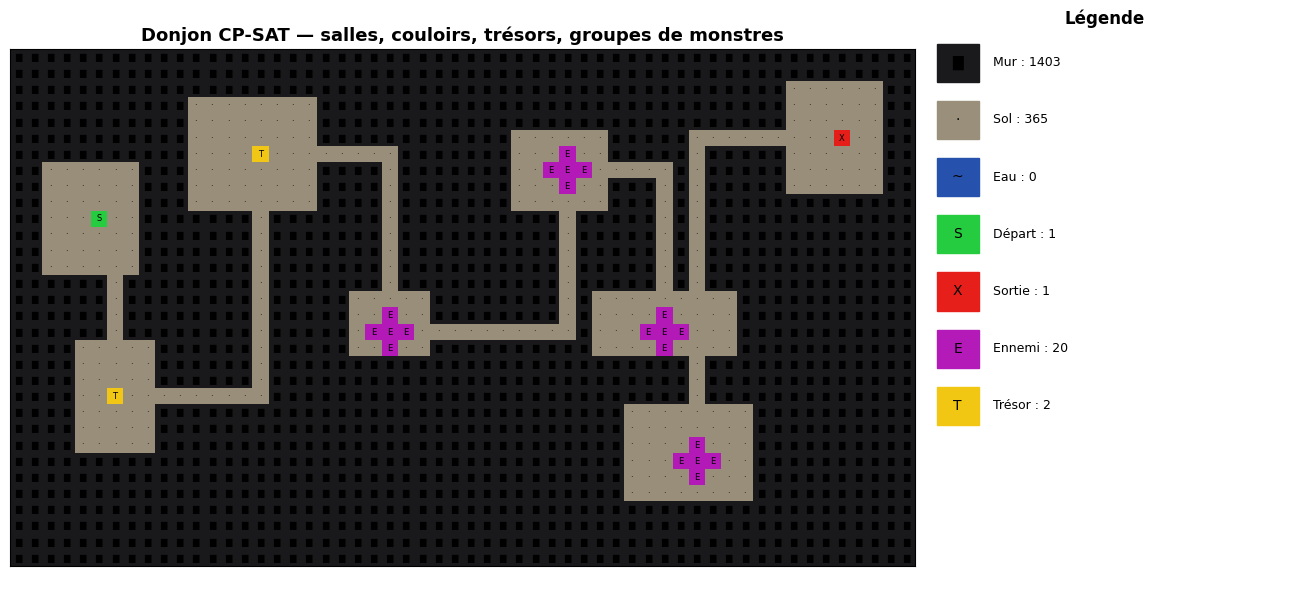

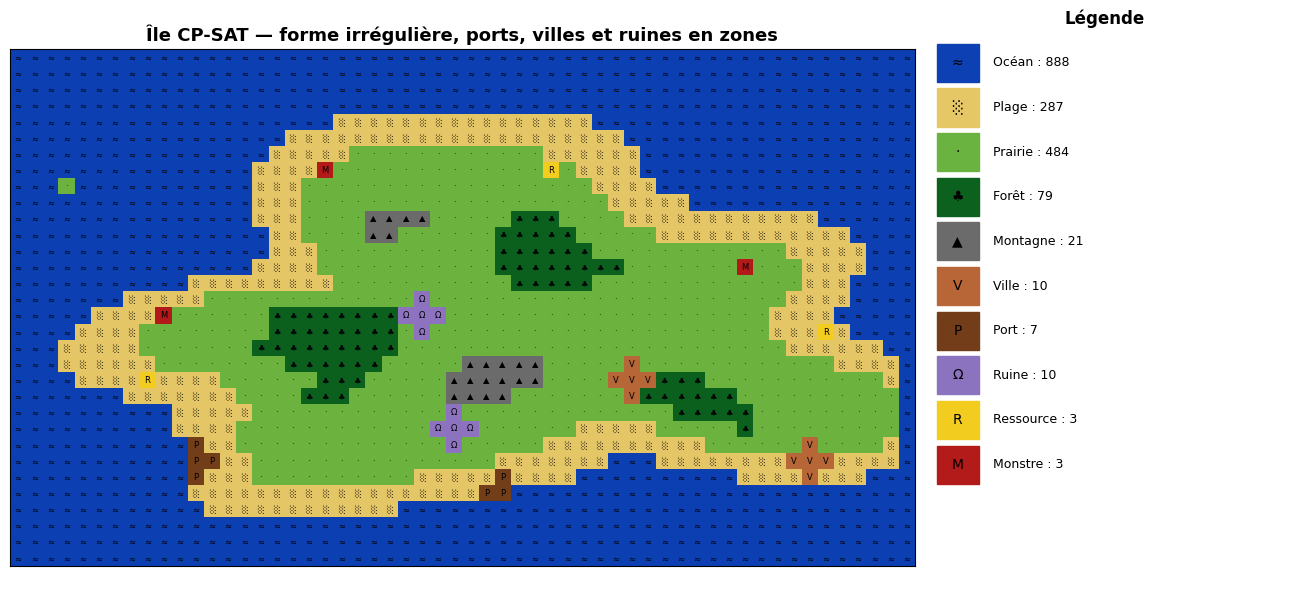

Groupes de monstres valides, aucun ennemi seul : True


In [6]:
dungeon_map = generate_by_method(dungeon, "cpsat")
island_map = generate_by_method(island, "cpsat")

display_level(dungeon_map, dungeon, "Donjon CP-SAT — salles, couloirs, trésors, groupes de monstres")
display_level(island_map, island, "Île CP-SAT — forme irrégulière, ports, villes et ruines en zones")

if dungeon_map is not None:
    print("Groupes de monstres valides, aucun ennemi seul :", enemy_groups_are_valid(dungeon_map))
else:
    print("CP-SAT indisponible ou aucune solution trouvée pour le donjon.")

if island_map is None:
    print("CP-SAT indisponible ou aucune solution trouvée pour l'île.")


## 7. Comparaison visuelle Random / WFC / CP-SAT


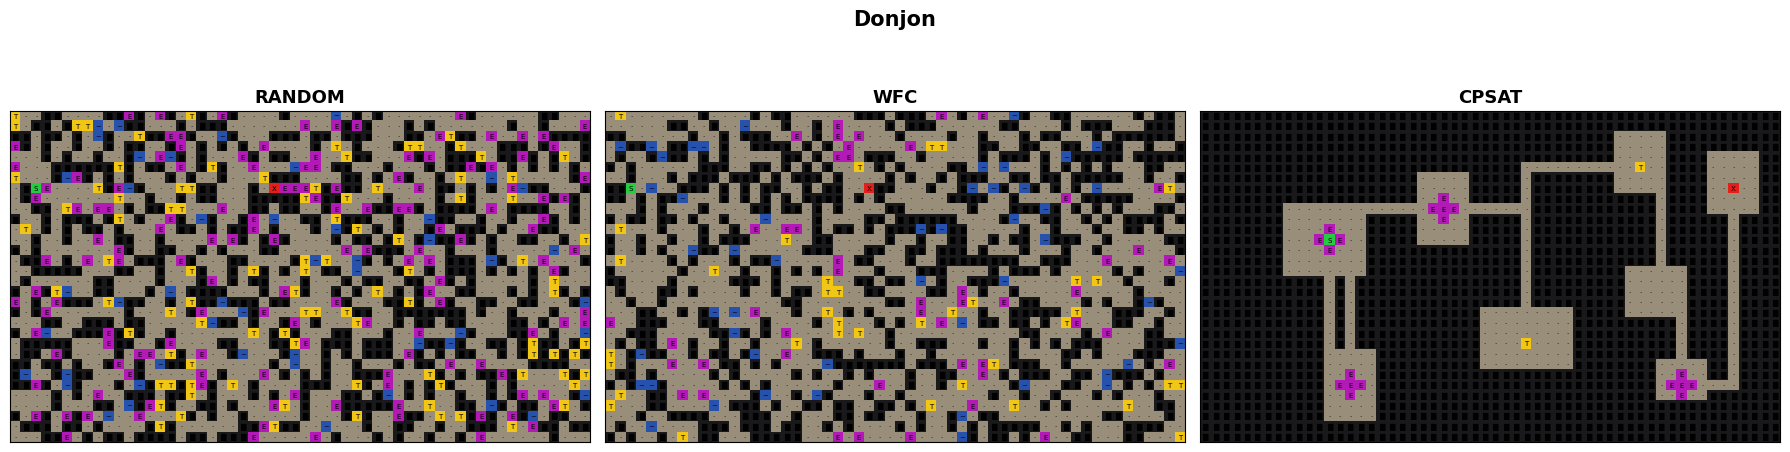

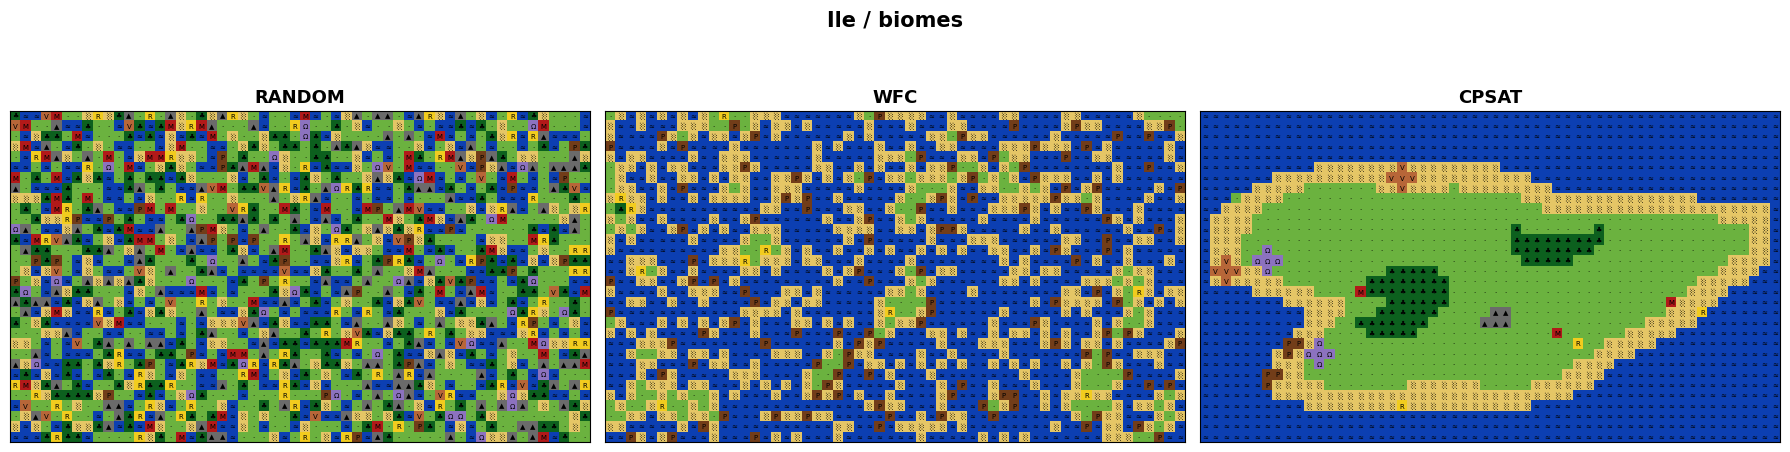

In [7]:
def compare_methods_visual(tileset):
    methods = ["random", "wfc", "cpsat"]
    grids = [generate_by_method(tileset, m) for m in methods]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
    for ax, method, grid in zip(axes, methods, grids):
        if grid is None:
            ax.axis("off")
            ax.set_title(f"{method} — échec")
            continue
        ax.imshow(tile_rgb(grid, tileset))
        ax.set_title(method.upper(), fontsize=13, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])
        fs = max(5, min(8, 160 // max(grid.shape)))
        for r in range(grid.shape[0]):
            for c in range(grid.shape[1]):
                ax.text(c, r, tileset.chars[grid[r,c]], ha="center", va="center", fontsize=fs)
    plt.suptitle(tileset.name, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()
    return grids

compare_methods_visual(dungeon)
isl=compare_methods_visual(island)


## 8. Métriques


In [8]:
def run_experiment(tileset, h=MAP_H, w=MAP_W, n=3):
    rows = []
    for method in ["random", "wfc", "cpsat"]:
        for _ in range(n):
            grid = generate_by_method(tileset, method)
            if grid is None:
                rows.append({"cas": tileset.name, "methode": method, "ok": False})
                continue
            m = level_metrics(grid, tileset)
            m.update({"cas": tileset.name, "methode": method, "ok": True})
            if tileset.name == "Donjon":
                m["ennemis_groupes_valides"] = enemy_groups_are_valid(grid)
            rows.append(m)
    return pd.DataFrame(rows)


df = pd.concat([run_experiment(dungeon), run_experiment(island)], ignore_index=True)
display(df.head())

summary = df.groupby(["cas", "methode"]).agg(
    taux_generation=("ok", "mean"),
    taux_chemin=("chemin_existe", "mean"),
    connectivite_moyenne=("ratio_connectivite", "mean"),
    chemin_moyen=("longueur_chemin", "mean"),
    variete_moyenne=("variete_tuiles", "mean"),
    adjacences_invalides_moy=("adjacences_invalides", "mean"),
    taux_adjacences_valides=("taux_adjacences_valides", "mean"),
).reset_index()

display(summary)


,nb_wall,nb_floor,nb_water,nb_spawn,nb_exit,nb_enemy,nb_treasure,chemin_existe,longueur_chemin,ratio_connectivite,...,nb_ocean,nb_beach,nb_grass,nb_forest,nb_mountain,nb_village,nb_port,nb_rune,nb_resource,nb_monster
0,615.0,869.0,48.0,1.0,1.0,158.0,100.0,False,NaN,0.025686,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,622.0,861.0,44.0,1.0,1.0,163.0,100.0,True,35.0,0.891652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,598.0,923.0,43.0,1.0,1.0,133.0,93.0,True,31.0,0.759340,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,603.0,1053.0,46.0,1.0,1.0,47.0,41.0,False,NaN,0.115486,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,611.0,1034.0,54.0,1.0,1.0,54.0,37.0,False,NaN,0.023070,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,cas,methode,taux_generation,taux_chemin,connectivite_moyenne,chemin_moyen,variete_moyenne,adjacences_invalides_moy,taux_adjacences_valides
0,Donjon,cpsat,1.0,0.000000,0.000000,NaN,6.000000,4.666667,0.998665
1,Donjon,random,1.0,0.666667,0.558893,33.000000,7.000000,370.000000,0.894165
2,Donjon,wfc,1.0,0.000000,0.225808,NaN,7.000000,0.000000,1.000000
3,Ile / biomes,cpsat,1.0,0.333333,0.334056,22.000000,10.000000,13.333333,0.996186
4,Ile / biomes,random,1.0,1.000000,0.956771,26.666667,10.000000,1320.000000,0.622426
5,Ile / biomes,wfc,1.0,0.000000,0.119351,NaN,8.666667,0.000000,1.000000


## 9. Tableaux compacts par méthode


Galerie donjon structuré


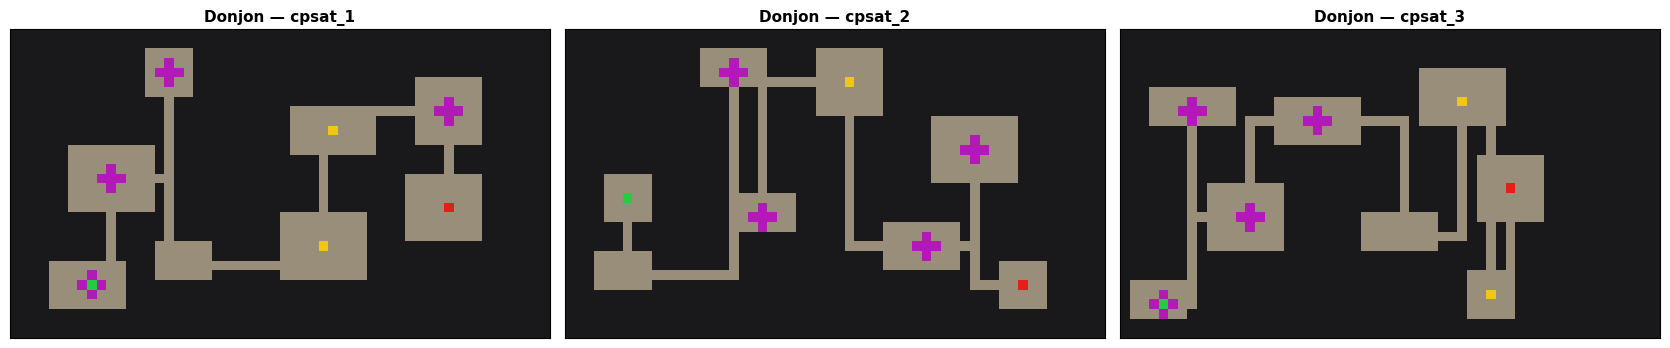

,carte,Mur,Sol,Eau,Départ,Sortie,Ennemi,Trésor
0,cpsat_1,1386,383,0,1,1,19,2
1,cpsat_2,1436,333,0,1,1,20,1
2,cpsat_3,1401,368,0,1,1,19,2


Galerie île structurée


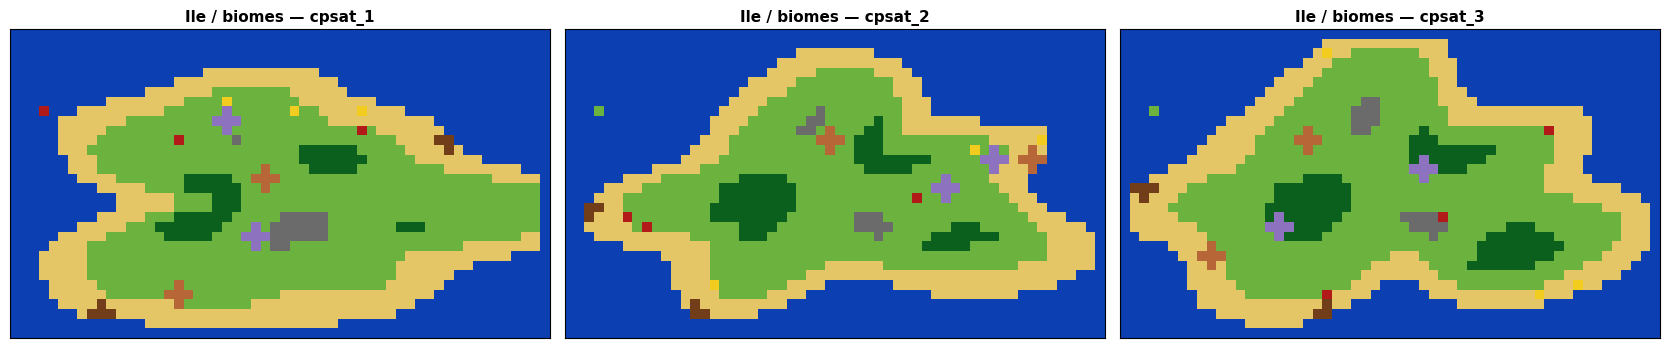

,carte,Océan,Plage,Prairie,Forêt,Montagne,Ville,Port,Ruine,Ressource,Monstre
0,cpsat_1,742,348,593,56,20,10,7,10,3,3
1,cpsat_2,874,307,484,82,13,10,6,10,3,3
2,cpsat_3,721,338,580,101,19,10,7,10,3,3


In [9]:
def compact_counts_table(grids, tileset, method):
    rows = []
    labels = tileset.labels or {t: t for t in tileset.tiles}
    for i, grid in enumerate(grids, start=1):
        counts = Counter(grid.flatten())
        row = {"carte": f"{method}_{i}"}
        for t in tileset.tiles:
            row[labels[t]] = counts[t]
        rows.append(row)
    return pd.DataFrame(rows)


def gallery(tileset, method, n=3):
    grids = []
    attempts = 0
    while len(grids) < n and attempts < n*5:
        attempts += 1
        g = generate_by_method(tileset, method)
        if g is not None:
            grids.append(g)
    if not grids:
        print("Aucune carte générée pour cette galerie.")
        return pd.DataFrame()
    fig, axes = plt.subplots(1, len(grids), figsize=(5.6*len(grids), 4.2))
    if len(grids) == 1:
        axes = [axes]
    for idx, (ax, grid) in enumerate(zip(axes, grids), start=1):
        ax.imshow(tile_rgb(grid, tileset))
        ax.set_title(f"{tileset.name} — {method}_{idx}", fontsize=11, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()
    return compact_counts_table(grids, tileset, method)

print("Galerie donjon structuré")
display(gallery(dungeon, "cpsat", n=3))
print("Galerie île structurée")
display(gallery(island, "cpsat", n=3))
